In [2]:
import numpy as np

In [1]:
from datetime import datetime
import os
import matplotlib.pyplot as plt
import pyart
import nexradaws
import cartopy.crs as ccrs
import colormaps as cmaps
import numpy as np

# 1) Connect to AWS NEXRAD Level II archive
conn = nexradaws.NexradAwsInterface()

# 2) Pick site + time window (UTC)
site = "KTLX"  # Oklahoma City
start = datetime(2023, 4, 19, 23, 0)   # YYYY, M, D, H, M (UTC)
end   = datetime(2023, 4, 20, 1, 00)

scans = conn.get_avail_scans_in_range(start, end, site)
print(f"Found {len(scans)} scans")
print(scans[:3])

# 3) Download one scan locally
out_dir = "./nexrad_l2_data"
os.makedirs(out_dir, exist_ok=True)

#




## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Found 21 scans
[<AwsNexradFile object - 2023/04/19/KTLX/KTLX20230419_230340_V06>, <AwsNexradFile object - 2023/04/19/KTLX/KTLX20230419_230841_V06>, <AwsNexradFile object - 2023/04/19/KTLX/KTLX20230419_231343_V06>]


In [14]:
 #choose first scan (or any index you want)
selected = [scans[-9]]
download_results = conn.download(selected, out_dir)

local_file = download_results.success[0].filepath
print("Downloaded:", local_file)

# 4) Read Level II radar volume
radar = pyart.io.read_nexrad_archive(local_file)

gatefilter = pyart.filters.GateFilter(radar)
gatefilter.exclude_transition() 

# 3. Apply the region-based dealiasing algorithm
# This unfolds aliased velocities by identifying connected regions and adjusting them
dealias_field = pyart.correct.dealias_region_based(
    radar, 
    gatefilter=gatefilter, 
    vel_field='velocity', 
    corr_vel_field='corrected_velocity'
)

# 4. Add the unfolded velocity field back into your radar object
radar.add_field('corrected_velocity', dealias_field)

Downloaded KTLX20230420_001002_V06
1 out of 1 files downloaded...0 errors
Downloaded: ./nexrad_l2_data/KTLX20230420_001002_V06


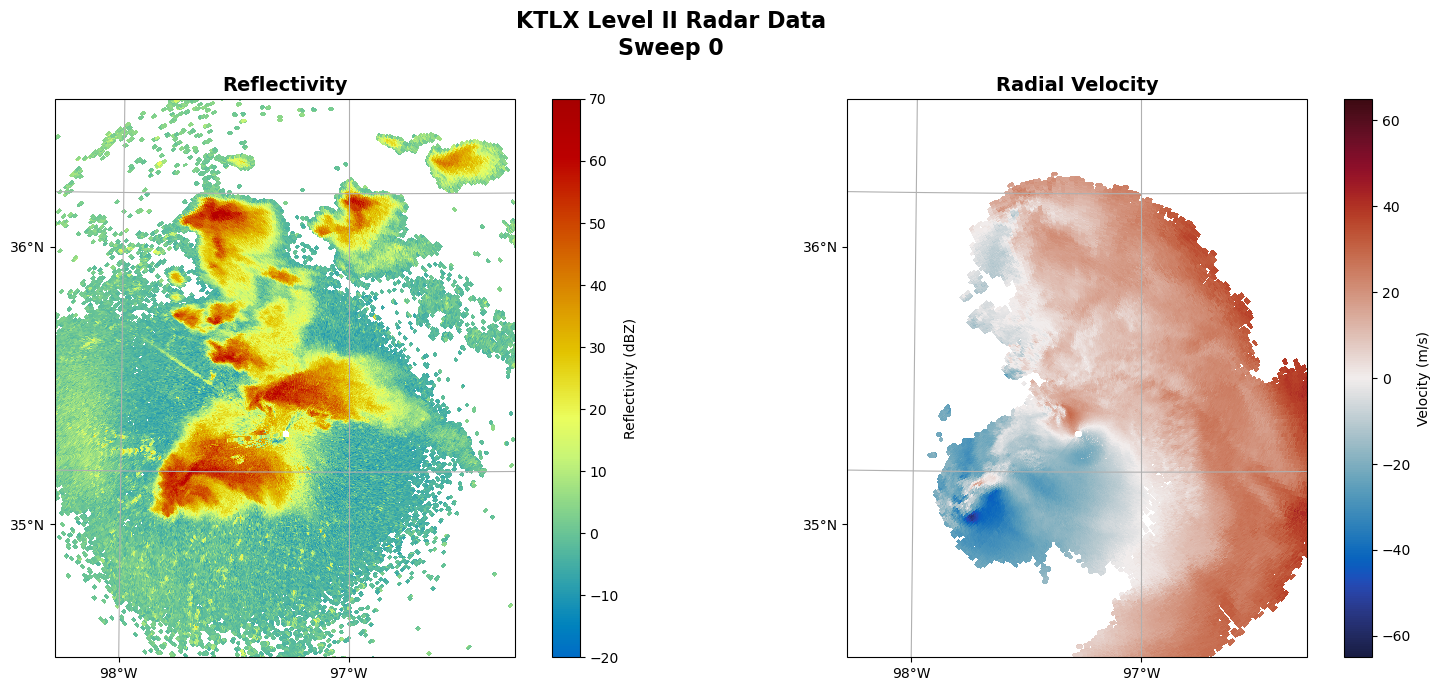

In [15]:
# Plot reflectivity and velocity side by side
fig = plt.figure(figsize=(16, 7))

# Left panel: Reflectivity
proj = ccrs.LambertConformal(central_latitude=35, central_longitude=-97)
ax1 = plt.subplot(1, 2, 1, projection=proj)

display1 = pyart.graph.RadarMapDisplay(radar)
display1.plot_ppi_map(
    "reflectivity",
    sweep=16,
    vmin=-20, vmax=70,
    cmap="HomeyerRainbow",
    min_lon=radar.longitude["data"][0] - 1.0,
    max_lon=radar.longitude["data"][0] + 1.0,
    min_lat=radar.latitude["data"][0] - 1.0,
    max_lat=radar.latitude["data"][0] + 1.0,
    lat_lines=[34, 35, 36, 37],
    lon_lines=[-99, -98, -97, -96],
    colorbar_label="Reflectivity (dBZ)",
    ax=ax1
)
ax1.set_title("Reflectivity", fontsize=14, fontweight='bold')

# Right panel: Velocity
ax2 = plt.subplot(1, 2, 2, projection=proj)

display2 = pyart.graph.RadarMapDisplay(radar)
display2.plot_ppi_map(
    "corrected_velocity",
    sweep=15,
    vmin=-65, vmax=65,
    cmap=cmaps.balance,
    min_lon=radar.longitude["data"][0] - 1.0,
    max_lon=radar.longitude["data"][0] + 1.0,
    min_lat=radar.latitude["data"][0] - 1.0,
    max_lat=radar.latitude["data"][0] + 1.0,
    lat_lines=[34, 35, 36, 37],
    lon_lines=[-99, -98, -97, -96],
    colorbar_label="Velocity (m/s)",
    ax=ax2
)
ax2.set_title("Radial Velocity", fontsize=14, fontweight='bold')

plt.suptitle(f"{site} Level II Radar Data\nSweep 0", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Plotting 23 sweeps
Elevation angles: [ 0.6427002   0.5960083   0.57403564 ... 19.511719   19.511719
 19.511719  ]


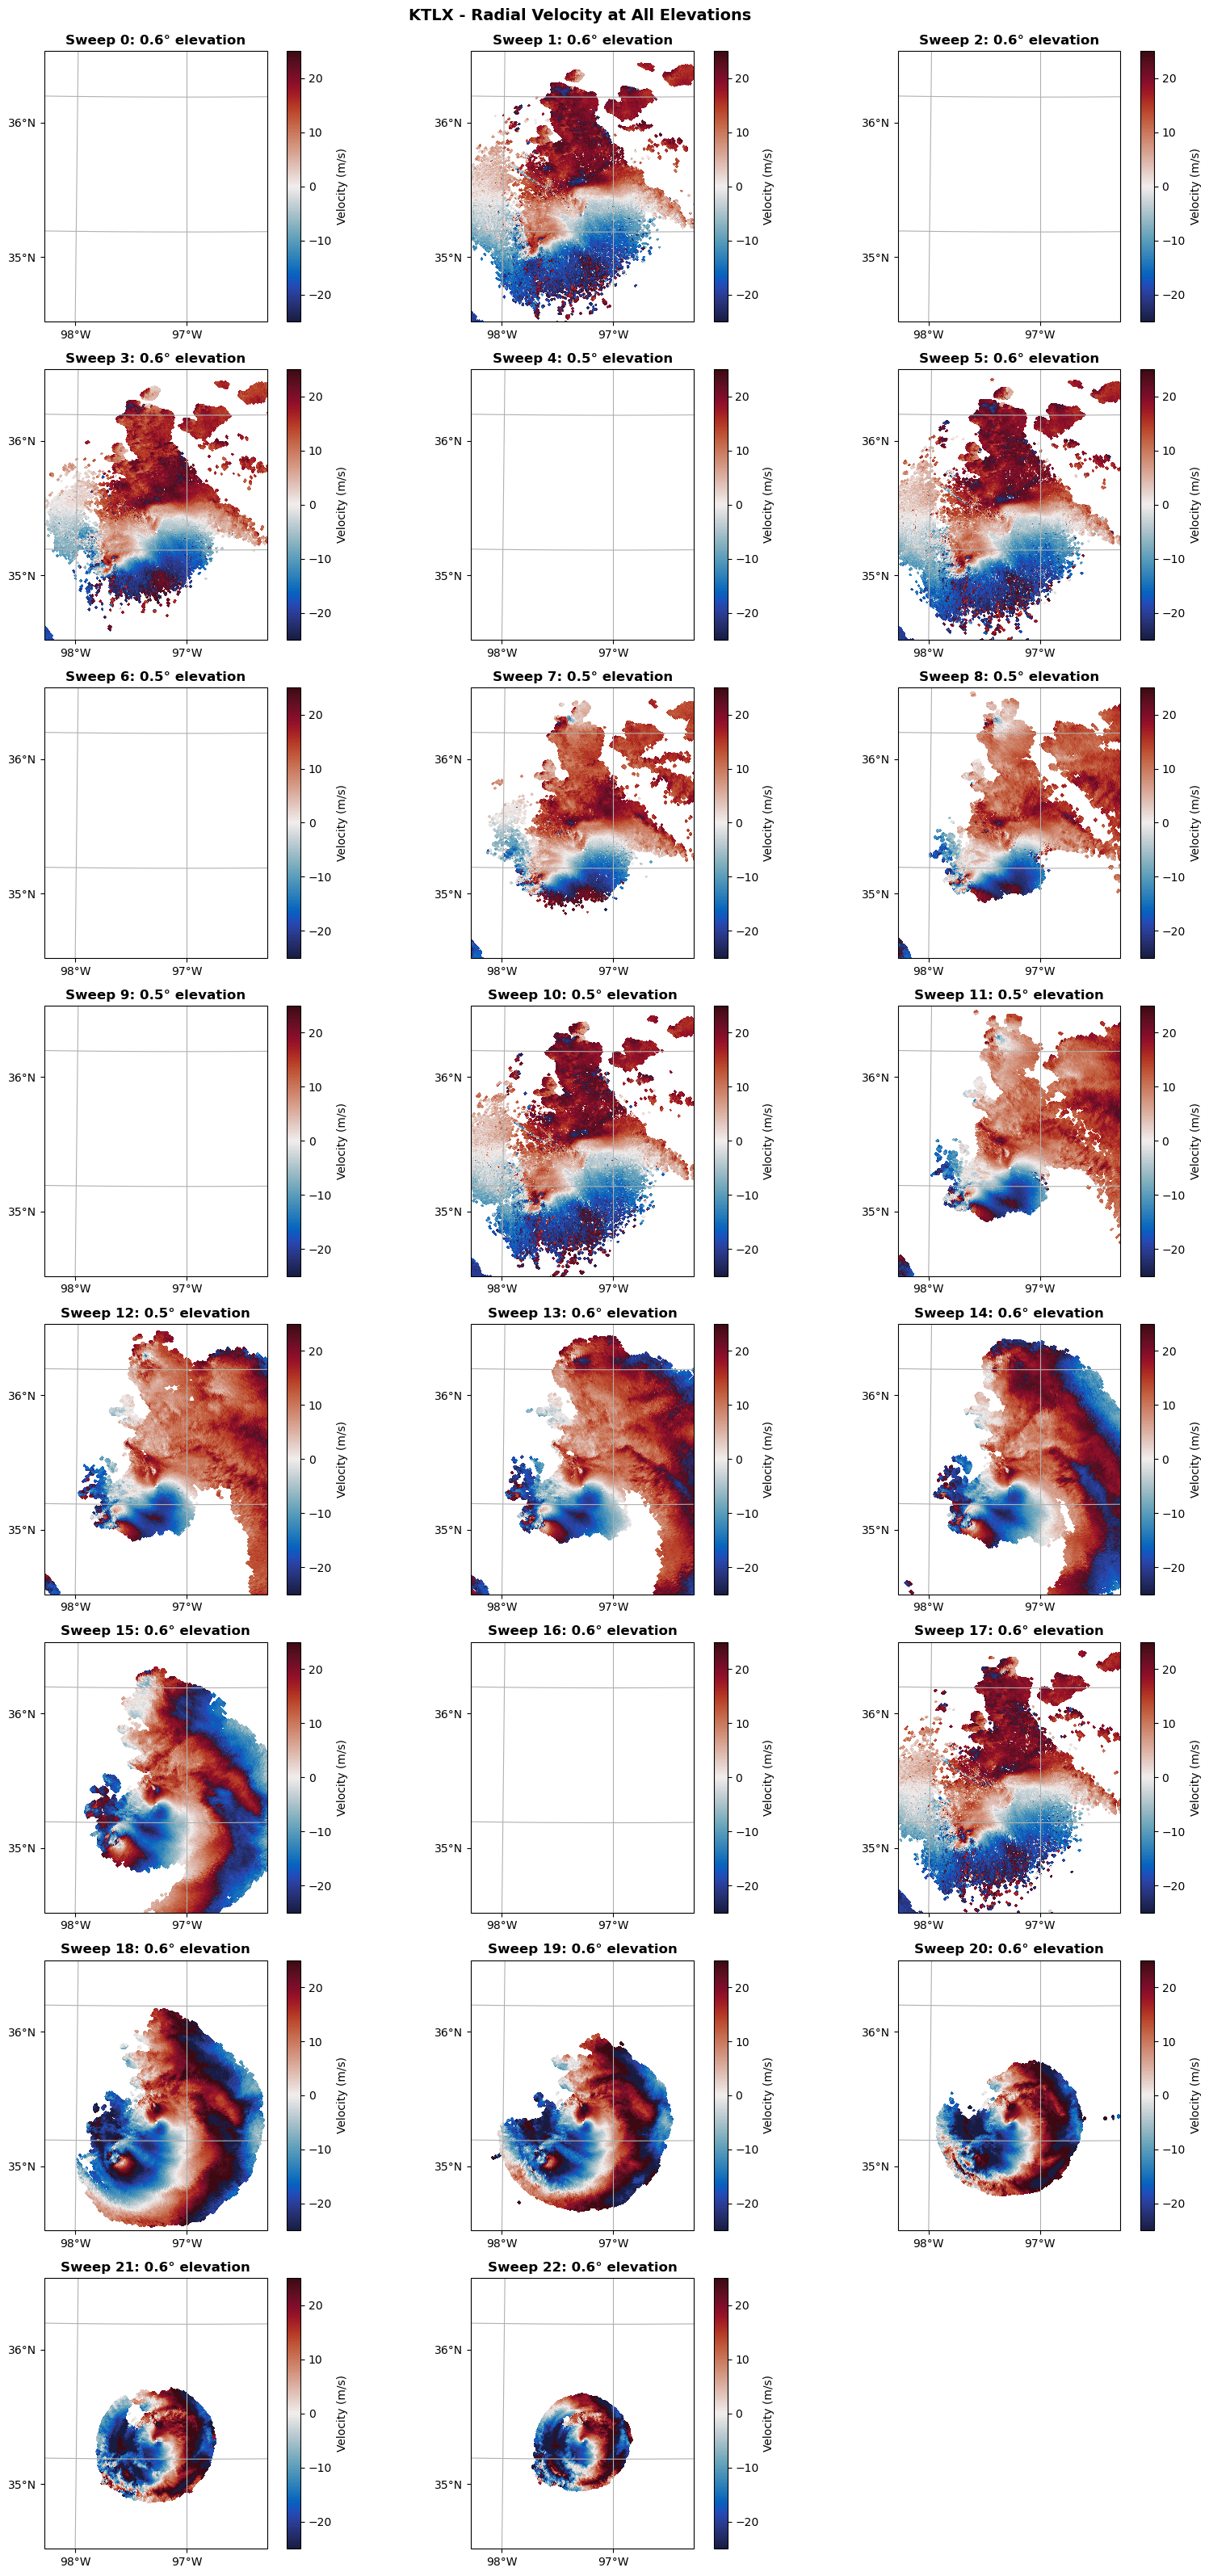

In [26]:
# Plot velocity at all elevation sweeps
nsweeps = radar.nsweeps
print(f"Plotting {nsweeps} sweeps")
print(f"Elevation angles: {radar.elevation['data']}")

# Create grid of subplots
ncols = 3
nrows = int(np.ceil(nsweeps / ncols))
fig = plt.figure(figsize=(16, 4*nrows))

for sweep in range(nsweeps):
    ax = plt.subplot(nrows, ncols, sweep+1, 
                     projection=ccrs.LambertConformal(central_latitude=35, central_longitude=-97))
    
    display = pyart.graph.RadarMapDisplay(radar)
    display.plot_ppi_map(
        "velocity",
        sweep=sweep,
        vmin=-25, vmax=25,
        cmap=cmaps.balance,
        min_lon=radar.longitude["data"][0] - 1.0,
        max_lon=radar.longitude["data"][0] + 1.0,
        min_lat=radar.latitude["data"][0] - 1.0,
        max_lat=radar.latitude["data"][0] + 1.0,
        colorbar_label="Velocity (m/s)",
        ax=ax
    )
    elev = radar.elevation['data'][sweep]
    ax.set_title(f"Sweep {sweep}: {elev:.1f}° elevation", fontweight='bold', fontsize=12)

plt.suptitle(f"{site} - Radial Velocity at All Elevations", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [16]:
radar.fields.keys()

dict_keys(['cross_correlation_ratio', 'differential_phase', 'reflectivity', 'spectrum_width', 'clutter_filter_power_removed', 'differential_reflectivity', 'velocity'])

In [22]:
radar.elevation['data'][45]

np.float32(0.49163818)

In [15]:
radar.get_elevation(sweep=10)

array([0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339844,
       0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339844,
       0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339844,
       0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339844,
       0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339844,
       0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339844,
       0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339844,
       0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339844,
       0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339844,
       0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339844,
       0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339844,
       0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339844,
       0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339844,
       0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339844,
       0.48339844, 0.48339844, 0.48339844, 0.48339844, 0.48339

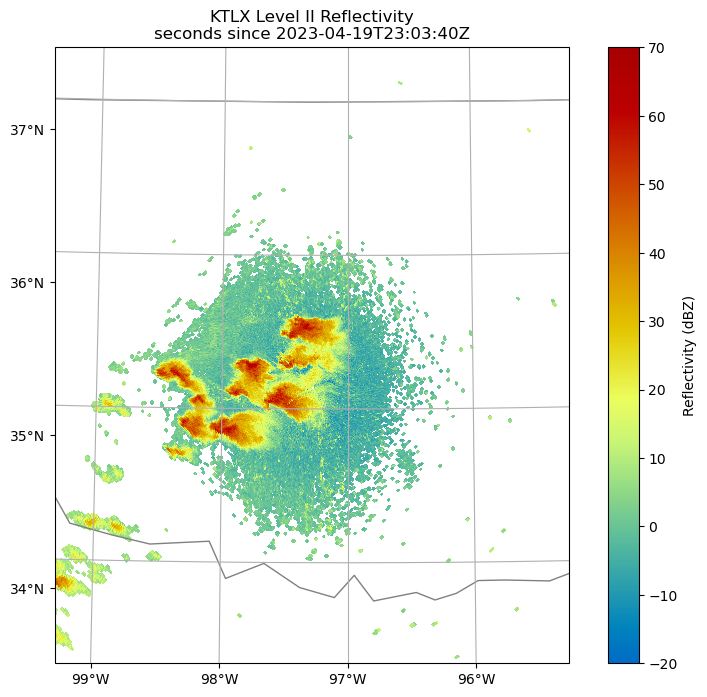

In [3]:
# 5) Plot base reflectivity for first sweep
display = pyart.graph.RadarMapDisplay(radar)
fig = plt.figure(figsize=(10, 8))

# Use cartopy.crs directly instead of pyart.graph.common.get_cartopy()
proj = ccrs.LambertConformal(central_latitude=35, central_longitude=-97)
ax = plt.axes(projection=proj)

display.plot_ppi_map(
    "reflectivity",              # common Level II field
    sweep=0,                     # 0 = lowest tilt
    vmin=-20, vmax=70,
    cmap="HomeyerRainbow",
    min_lon=radar.longitude["data"][0] - 2.0,
    max_lon=radar.longitude["data"][0] + 2.0,
    min_lat=radar.latitude["data"][0] - 2.0,
    max_lat=radar.latitude["data"][0] + 2.0,
    lat_lines=[34, 35, 36, 37],
    lon_lines=[-99, -98, -97, -96],
    colorbar_label="Reflectivity (dBZ)",
    ax=ax
)
plt.title(f"{site} Level II Reflectivity\n{radar.time['units']}")
plt.show()

In [ ]:

import numpy as np
import netCDF4 as ncdf
import datetime
import sys
from time import time as timer

from pyDart import dxy_2_dll
import state_vector as state
from ens import ensemble, time_all   # reuse the same class/flag from ens.py


# ─── C-grid (staggered) → A-grid (cell-centred) ─────────────────────────────

def _c2a_py(u_stag, v_stag, w_stag, nx, ny, nz):
    """
    De-stagger C-grid face velocities to cell centres.

    Uses the 4th-order Sanderson & Brassington (1998) scheme for interior
    points and simple 2nd-order averaging at the two boundary faces — matching
    the formula used in ens_CM1_C2A.

        u(i) = (-u(i-3/2) + 13*u(i-1/2) + 13*u(i+1/2) - u(i+3/2)) / 24

    Parameters
    ----------
    u_stag : (ne, nz,   ny,   nx+1)  x-face values
    v_stag : (ne, nz,   ny+1, nx  )  y-face values
    w_stag : (ne, nz+1, ny,   nx  )  z-face values

    Returns
    -------
    ua, va, wa  –  each (ne, nz, ny, nx)
    """
    ne = u_stag.shape[0]

    # U  –  stagger in last dimension (x)
    ua = np.empty((ne, nz, ny, nx), dtype=np.float32)
    ua[:, :, :, 0]      = 0.5 * (u_stag[:, :, :, 0]    + u_stag[:, :, :, 1])
    ua[:, :, :, nx-1]   = 0.5 * (u_stag[:, :, :, nx-1] + u_stag[:, :, :, nx])
    ua[:, :, :, 1:nx-1] = (  -u_stag[:, :, :, 0:nx-2]
                            + 13*u_stag[:, :, :, 1:nx-1]
                            + 13*u_stag[:, :, :, 2:nx  ]
                               -u_stag[:, :, :, 3:nx+1] ) / 24.0

    # V  –  stagger in second-to-last dimension (y)
    va = np.empty((ne, nz, ny, nx), dtype=np.float32)
    va[:, :, 0, :]      = 0.5 * (v_stag[:, :, 0, :]    + v_stag[:, :, 1, :])
    va[:, :, ny-1, :]   = 0.5 * (v_stag[:, :, ny-1, :] + v_stag[:, :, ny, :])
    va[:, :, 1:ny-1, :] = (  -v_stag[:, :, 0:ny-2, :]
                            + 13*v_stag[:, :, 1:ny-1, :]
                            + 13*v_stag[:, :, 2:ny,   :]
                               -v_stag[:, :, 3:ny+1,  :] ) / 24.0

    # W  –  stagger in z (axis 1)
    wa = np.empty((ne, nz, ny, nx), dtype=np.float32)
    wa[:, 0, :, :]      = 0.5 * (w_stag[:, 0, :, :]    + w_stag[:, 1, :, :])
    wa[:, nz-1, :, :]   = 0.5 * (w_stag[:, nz-1, :, :] + w_stag[:, nz, :, :])
    wa[:, 1:nz-1, :, :] = (  -w_stag[:, 0:nz-2, :, :]
                            + 13*w_stag[:, 1:nz-1, :, :]
                            + 13*w_stag[:, 2:nz,   :, :]
                               -w_stag[:, 3:nz+1,  :, :] ) / 24.0

    return ua, va, wa


# ─── main reader ─────────────────────────────────────────────────────────────

def read_CM1_ens_py(files, experiment, state_vector=None,
                    DateTime=None, time_index=None, addmean=0):
    """
    Pure-Python replacement for read_CM1_ens + ens_CM1_C2A.

    Reads a CM1 ensemble from netCDF restart files and returns the same
    ``ensemble`` object as the Fortran-backed version, using plain NumPy
    arrays instead of Fortran shared memory.

    Staggered U/V/W are de-staggered to cell centres via _c2a_py().
    Raw staggered arrays are retained as ._u_stag, ._v_stag, ._w_stag
    so that write-back routines can reconstruct them if needed.

    Usage is identical to the original::

        ens_state = read_CM1_ens_py(files, exper, DateTime=myDT, addmean=1)
        ens_CM1_coords_py(ens_state)
    """
    t0 = timer()

    if DateTime is None and time_index is None:
        print("\n READ_CM1_ENS_PY ==> FATAL ERROR: supply DateTime or time_index")
        sys.exit(1)

    ens_obj = ensemble("CM1")

    # ── metadata from first file ───────────────────────────────────────────
    with ncdf.Dataset(files[0]) as f0:
        ne = len(files)
        addmean = min(addmean, 1)   # clamp to 0 or 1

        ens_obj.files        = files
        ens_obj.nx           = len(f0.dimensions['ni'])
        ens_obj.ny           = len(f0.dimensions['nj'])
        ens_obj.nz           = len(f0.dimensions['nk'])
        ens_obj.ne           = ne
        ens_obj.addmean      = addmean
        ens_obj.year         = int(experiment['YEAR'])
        ens_obj.month        = int(experiment['MONTH'])
        ens_obj.day          = int(experiment['DAY'])
        ens_obj.hour         = int(experiment['HOUR'])
        ens_obj.minute       = int(experiment['MINUTE'])
        ens_obj.second       = int(experiment['SECOND'])
        ens_obj.hgt          = float(experiment['hgt'])
        ens_obj.microphysics = experiment['microphysics']
        ens_obj.xg_pos       = experiment['xoffset']
        ens_obj.yg_pos       = experiment['yoffset']
        ens_obj.lat0         = experiment['lat0']
        ens_obj.lon0         = experiment['lon0']
        ens_obj.experiment   = experiment
        ens_obj.BackUpFiles  = []

        ens_obj.coards   = datetime.datetime(ens_obj.year, ens_obj.month, ens_obj.day,
                                              ens_obj.hour, ens_obj.minute, ens_obj.second)
        ens_obj.time     = float(f0.variables['time'][0])
        ens_obj.datetime = [ens_obj.coards + datetime.timedelta(seconds=int(ens_obj.time))]

        # match state vector to microphysics scheme
        if state_vector is None:
            try:
                ens_obj.state_vector = state.__dict__[ens_obj.microphysics]
                print(f"\n ==> READ_CM1_ENS_PY: matched state_vector '{ens_obj.microphysics}'")
            except KeyError:
                print(f"\n ==> READ_CM1_ENS_PY: no state_vector for '{ens_obj.microphysics}'")
                sys.exit(-1)
        else:
            ens_obj.state_vector = state_vector

        ens_obj.nxyz3d = ens_obj.state_vector['nxyz3d']

        if time_index is None:
            time_index = 0
        ens_obj.time_index = time_index

        print(f"\n ==> READ_CM1_ENS_PY: time index {time_index}"
              f"  ({ens_obj.datetime[time_index]})")

        # ── read 1-D coordinates ───────────────────────────────────────────
        for key in ens_obj.state_vector["coords"]:
            cname = ens_obj.state_vector[key]['name']
            if cname not in f0.variables:
                print(f"\n WARNING: coord '{key}' ({cname}) not in file – skipping")
                continue
            d = f0.variables[cname]
            data = (d[time_index]
                    if (d.ndim == 1 and d.dimensions[0] == 'TIME')
                    else np.array(d[:], dtype=np.float32))
            ens_obj.addvariable(key, data=data)
            for attr in d.ncattrs():
                ens_obj.addattribute(key, attr, d.getncattr(attr))

    nx, ny, nz = ens_obj.nx, ens_obj.ny, ens_obj.nz
    ne_alloc   = ne + addmean   # extra slot at the end for the ensemble mean

    # ── allocate arrays ────────────────────────────────────────────────────
    # Staggered storage (kept for write-back if needed)
    u_stag = np.zeros((ne_alloc, nz,   ny,   nx + 1), dtype=np.float32)
    v_stag = np.zeros((ne_alloc, nz,   ny + 1, nx  ), dtype=np.float32)
    w_stag = np.zeros((ne_alloc, nz+1, ny,   nx    ), dtype=np.float32)

    # Cell-centred storage: (n_state_vars, ne_alloc, nz, ny, nx)
    xyz3d  = np.zeros((ens_obj.nxyz3d, ne_alloc, nz, ny, nx), dtype=np.float32)

    u_ptr = v_ptr = w_ptr = None

    # ── read each member ───────────────────────────────────────────────────
    t1 = timer()
    for n, fi in enumerate(files[:ne]):
        with ncdf.Dataset(fi, "r") as f:
            for m, key in enumerate(ens_obj.state_vector['xyz3d']):
                hkey = ens_obj.state_vector[key]['name']
                if hkey not in f.variables:
                    print(f"\n WARNING: '{key}' ({hkey}) not found in {fi}")
                    continue
                if key == "U":
                    u_stag[n] = f[hkey][0]   # (nz, ny, nx+1)
                    u_ptr = m
                elif key == "V":
                    v_stag[n] = f[hkey][0]   # (nz, ny+1, nx)
                    v_ptr = m
                elif key == "W":
                    w_stag[n] = f[hkey][0]   # (nz+1, ny, nx)
                    w_ptr = m
                else:
                    xyz3d[m, n] = f[hkey][0] # (nz, ny, nx)

    if time_all:
        print(f"\n Wallclock: serial netCDF read      {round(timer()-t1, 3)} s")

    # ── de-stagger U/V/W → cell centres ───────────────────────────────────
    t2 = timer()
    ua, va, wa = _c2a_py(u_stag[:ne], v_stag[:ne], w_stag[:ne], nx, ny, nz)
    if u_ptr is not None: xyz3d[u_ptr, :ne] = ua
    if v_ptr is not None: xyz3d[v_ptr, :ne] = va
    if w_ptr is not None: xyz3d[w_ptr, :ne] = wa
    if time_all:
        print(f"\n Wallclock: C→A de-stagger          {round(timer()-t2, 3)} s")

    # ── ensemble mean ──────────────────────────────────────────────────────
    if addmean > 0:
        t3 = timer()
        # Mean of the cell-centred fields (index ne = last slot)
        xyz3d[:, ne] = xyz3d[:, :ne].mean(axis=1)
        # Mean of the staggered fields (needed if write-back is called later)
        u_stag[ne]   = u_stag[:ne].mean(axis=0)
        v_stag[ne]   = v_stag[:ne].mean(axis=0)
        w_stag[ne]   = w_stag[:ne].mean(axis=0)
        if time_all:
            print(f"\n Wallclock: ensemble mean           {round(timer()-t3, 3)} s")

    # ── store everything on the ensemble object ────────────────────────────
    ens_obj.u_ptr   = u_ptr
    ens_obj.v_ptr   = v_ptr
    ens_obj.w_ptr   = w_ptr
    ens_obj._u_stag = u_stag
    ens_obj._v_stag = v_stag
    ens_obj._w_stag = w_stag
    ens_obj._xyz3d  = xyz3d

    # Point ens variable objects at the numpy slices
    for m, key in enumerate(ens_obj.state_vector['xyz3d']):
        ens_obj.addvariable(key, data=xyz3d[m], coords='MEMBER,NZ,NY,NX')

    # Also expose A-grid velocities as UA/VA/WA (mirrors ens_CM1_C2A output)
    if u_ptr is not None:
        ens_obj.addvariable("UA", data=xyz3d[u_ptr], coords='MEMBER,NZ,NY,NX')
    if v_ptr is not None:
        ens_obj.addvariable("VA", data=xyz3d[v_ptr], coords='MEMBER,NZ,NY,NX')
    if w_ptr is not None:
        ens_obj.addvariable("WA", data=xyz3d[w_ptr], coords='MEMBER,NZ,NY,NX')

    if time_all:
        print(f"\n Wallclock: read_CM1_ens_py total   {round(timer()-t0, 3)} s")

    return ens_obj


# ─── coordinate helper ───────────────────────────────────────────────────────

def ens_CM1_coords_py(ens_obj):
    """
    Pure-Python replacement for ens_CM1_coords.

    Converts x/y grid positions (with domain offsets) to geographic lat/lon
    and attaches both lat/lon and offset Cartesian arrays to the ensemble
    object.  These take the place of the fstate grid arrays used by the
    Fortran version.

    After calling this function the ensemble object has:
        .latc / .lonc   – 1-D lat/lon at cell centres
        .late           – 1-D lat at y-staggered (V) points
        .lone           – 1-D lon at x-staggered (U) points
        .xc_global / .yc_global  – cell-centre x/y with domain offset added
        .xe_global / .ye_global  – edge x/y with domain offset added
        .zc_global / .ze_global  – z coordinates with terrain height added
        .dx / .dy                – grid spacing in metres
    """
    t0 = timer()

    # cell-centre lat/lon
    latc, lonc = dxy_2_dll(ens_obj.xc[:] + ens_obj.xg_pos,
                            ens_obj.yc[:] + ens_obj.yg_pos,
                            ens_obj.lat0, ens_obj.lon0, degrees=True)
    ens_obj.latc = np.array(latc)
    ens_obj.lonc = np.array(lonc)

    # y-staggered lat  (V-grid; xc stays the same, ye varies)
    late, _ = dxy_2_dll(ens_obj.xc[:] + ens_obj.xg_pos,
                         ens_obj.ye[:] + ens_obj.yg_pos,
                         ens_obj.lat0, ens_obj.lon0, degrees=True)
    ens_obj.late = np.array(late)

    # x-staggered lon  (U-grid; xe varies, yc stays the same)
    _, lone = dxy_2_dll(ens_obj.xe[:] + ens_obj.xg_pos,
                         ens_obj.yc[:] + ens_obj.yg_pos,
                         ens_obj.lat0, ens_obj.lon0, degrees=True)
    ens_obj.lone = np.array(lone)

    # offset Cartesian arrays (equivalent to fstate.xc, fstate.yc, etc.)
    ens_obj.xc_global = ens_obj.xc[:] + ens_obj.xg_pos
    ens_obj.yc_global = ens_obj.yc[:] + ens_obj.yg_pos
    ens_obj.xe_global = ens_obj.xe[:] + ens_obj.xg_pos
    ens_obj.ye_global = ens_obj.ye[:] + ens_obj.yg_pos
    ens_obj.zc_global = ens_obj.zc[:] + ens_obj.hgt
    ens_obj.ze_global = ens_obj.ze[:] + ens_obj.hgt

    ens_obj.dx = float(ens_obj.xe[1] - ens_obj.xe[0])
    ens_obj.dy = float(ens_obj.ye[1] - ens_obj.ye[0])

    if time_all:
        print(f"\n Wallclock: ens_CM1_coords_py       {round(timer()-t0, 3)} s")


In [2]:
import sys
sys.path.append('src/')
sys.path.append('src/fsrc/')
import ens
sys.path.append('fsrc/')
from fpython2 import fstate, addbubbles_box, obs_2_grid3d
from fpython2 import add_smooth_perts
#import fsrc.recursive2d as recursive2d
import datetime as dt
import state_vector as state
import json

PRIOR =False
fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4/'

time = dt.datetime(2024,5,8,21,30)

with open(f'{fpath}letkf.exp', 'rb') as f:exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, time, ret_exp=False, prior=PRIOR)

# ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1) # the final member is the mean member!!!!
# ens.ens_CM1_coords(ens_state)


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 21:30:00

 ==> FindRestartFile:  Found time 7200 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4/member001/cm1rst_000032.nc


In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

def _c2a_py(u_stag, v_stag, w_stag, nx, ny, nz, ne=36):
    """
    De-stagger C-grid face velocities to cell centres.

    Uses the 4th-order Sanderson & Brassington (1998) scheme for interior
    points and simple 2nd-order averaging at the two boundary faces — matching
    the formula used in ens_CM1_C2A.

        u(i) = (-u(i-3/2) + 13*u(i-1/2) + 13*u(i+1/2) - u(i+3/2)) / 24

    Parameters
    ----------
    u_stag : (ne, nz,   ny,   nx+1)  x-face values
    v_stag : (ne, nz,   ny+1, nx  )  y-face values
    w_stag : (ne, nz+1, ny,   nx  )  z-face values

    Returns
    -------
    ua, va, wa  –  each (ne, nz, ny, nx)
    """
    ne = u_stag.shape[0]

    # U  –  stagger in last dimension (x)
    ua = np.empty((ne, nz, ny, nx), dtype=np.float32)
    ua[:, :, :, 0]      = 0.5 * (u_stag[:, :, :, 0]    + u_stag[:, :, :, 1])
    ua[:, :, :, nx-1]   = 0.5 * (u_stag[:, :, :, nx-1] + u_stag[:, :, :, nx])
    ua[:, :, :, 1:nx-1] = (  -u_stag[:, :, :, 0:nx-2]
                            + 13*u_stag[:, :, :, 1:nx-1]
                            + 13*u_stag[:, :, :, 2:nx  ]
                               -u_stag[:, :, :, 3:nx+1] ) / 24.0

    # V  –  stagger in second-to-last dimension (y)
    va = np.empty((ne, nz, ny, nx), dtype=np.float32)
    va[:, :, 0, :]      = 0.5 * (v_stag[:, :, 0, :]    + v_stag[:, :, 1, :])
    va[:, :, ny-1, :]   = 0.5 * (v_stag[:, :, ny-1, :] + v_stag[:, :, ny, :])
    va[:, :, 1:ny-1, :] = (  -v_stag[:, :, 0:ny-2, :]
                            + 13*v_stag[:, :, 1:ny-1, :]
                            + 13*v_stag[:, :, 2:ny,   :]
                               -v_stag[:, :, 3:ny+1,  :] ) / 24.0

    # W  –  stagger in z (axis 1)
    wa = np.empty((ne, nz, ny, nx), dtype=np.float32)
    wa[:, 0, :, :]      = 0.5 * (w_stag[:, 0, :, :]    + w_stag[:, 1, :, :])
    wa[:, nz-1, :, :]   = 0.5 * (w_stag[:, nz-1, :, :] + w_stag[:, nz, :, :])
    wa[:, 1:nz-1, :, :] = (  -w_stag[:, 0:nz-2, :, :]
                            + 13*w_stag[:, 1:nz-1, :, :]
                            + 13*w_stag[:, 2:nz,   :, :]
                               -w_stag[:, 3:nz+1,  :, :] ) / 24.0

    return ua, va, wa

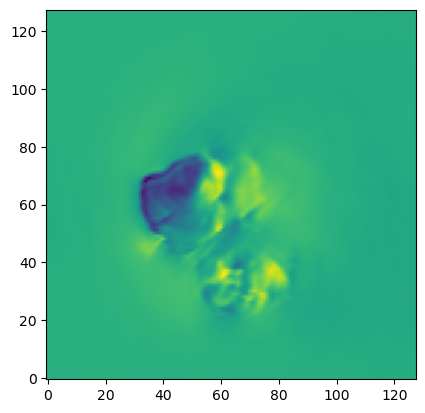

In [14]:
#np.shape(ens_state['U'][:])
plt.imshow(ens_state['U'][0, 0, :, :], origin='lower')

In [38]:
files

['/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4/member001/cm1rst_000032.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4/member002/cm1rst_000032.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4/member003/cm1rst_000032.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4/member004/cm1rst_000032.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4/member005/cm1rst_000032.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4/member006/cm1rst_000032.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4/member007/cm1rst_000032.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4/member008/cm1rst_000032.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4/member009/cm1rst_000032.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4/member010/cm1rst_000032.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4/member011/cm1rst_

In [ ]:
import os
import glob
import numpy as np
import xarray as xr

# assumes your existing _c2a_py(u_stag, v_stag, w_stag, nx, ny, nz) is already defined

def _destagger_with_c2a(ds, u_name="ua", v_name="va", w_name="wa"):
    # pick a mass-grid variable to get canonical output dims/coords
    mass_candidates = ["theta", "th", "dbz", "prs", "qv"]
    mass_name = next(v for v in mass_candidates if v in ds.data_vars)
    zdim, ydim, xdim = ds[mass_name].dims[-3:]

    u = ds[u_name].values
    v = ds[v_name].values
    w = ds[w_name].values

    # collapse all leading dims into "ne" for _c2a_py (usually just time=1 here)
    lead_shape = u.shape[:-3]
    ne = int(np.prod(lead_shape)) if lead_shape else 1

    nz = u.shape[-3]
    ny = u.shape[-2]
    nx = u.shape[-1] - 1  # staggered x has +1

    u_r = u.reshape((ne, nz, ny, nx + 1))
    v_r = v.reshape((ne, nz, ny + 1, nx))
    w_r = w.reshape((ne, nz + 1, ny, nx))

    u_c, v_c, w_c = _c2a_py(u_r, v_r, w_r, nx, ny, nz)

    # restore original leading dims
    out_shape = lead_shape + (nz, ny, nx)
    u_c = u_c.reshape(out_shape)
    v_c = v_c.reshape(out_shape)
    w_c = w_c.reshape(out_shape)

    out_dims = ds[u_name].dims[:-3] + (zdim, ydim, xdim)

    # attach mass-grid coords for x/y/z + keep all existing non-conflicting coords
    ds = ds.assign(
        u=(out_dims, u_c.astype(np.float32)),
        v=(out_dims, v_c.astype(np.float32)),
        w=(out_dims, w_c.astype(np.float32)),
    )

    # drop staggered winds once converted
    ds = ds.drop_vars([u_name, v_name, w_name], errors="ignore")
    return ds


# ---------- file list: nested [member][time] ----------
base = "/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H18_V6"
n_members = 36

paths_by_member = []
for m in range(1, n_members + 1):
    member_dir = os.path.join(base, f"member{m:03d}")
    paths = sorted(glob.glob(os.path.join(member_dir, "*rst_*.nc")))
    indices = [idx for idx, text in enumerate(paths) if files[0].split('/')[-1] in text]
    paths_by_member.append(paths[indices[0]:])

# keep minimal vars + staggered winds needed for conversion
keep_vars = ["ua", "va", "wa", "dbz", "theta", "prs", "qv"]

def preprocess(ds):
    vars_here = [v for v in keep_vars if v in ds.data_vars]
    ds = ds[vars_here]
    ds = _destagger_with_c2a(ds, u_name="ua", v_name="va", w_name="wa")
    return ds

ens_temp = xr.open_mfdataset(
    paths_by_member,                 # 2D list [member][time]
    combine="nested",
    concat_dim=["member", "time"],
    preprocess=preprocess,
    engine="netcdf4",
    parallel=False,                  # important for netcdf4 stability
    #lock=True,                       # important for netcdf4 stability
    data_vars="minimal",
    coords="minimal",
    compat="override",
    join="override",
    decode_cf=False,
    mask_and_scale=False,
    chunks={"member": 1, "time": 1}
).assign_coords(member=np.arange(0, len(paths_by_member)))

# optional: drop singleton time
# if ens.sizes.get("time", 0) == 1:
#     ens = ens.isel(time=0, drop=True)

# add derived variables after assembly
#ens["cdbz"] = ens["dbz"].max("nk")

In [23]:
#with xr.open_dataset(files) as ds:
cm1 = xr.open_dataset(files[0], decode_times=True)
u, v, w = _c2a_py([ ], cm1['va'][0].values, cm1['wa'][0].values,
                  cm1.sizes['ni'],cm1.sizes['nj'],cm1.sizes['nk'], ne=1)

/tmp/ipykernel_2506354/3980287721.py:2: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  cm1 = xr.open_dataset(files[0], decode_times=True)


TypeError: list indices must be integers or slices, not tuple

In [ ]:
keep_vars = ["ua", "va", "wa", "dbz", "theta", 'prs', 'qv']  # your list
#paths = [f"/work/.../member{m:03d}/cm1out_rst_000120.nc" for m in range(1, 37)]

def keep_only(ds):
    # keep only requested vars that actually exist in this file
    vars_here = [v for v in keep_vars if v in ds.data_vars]
    # optionally keep some coordinates explicitly if needed
    coord_keep = [c for c in ['time', "xh", "yh", "zh", "xf", "yf", "zf"] if c in ds.coords]
    return ds[vars_here].set_coords(coord_keep)

ens_temp = xr.open_mfdataset(
    files,
    combine="nested",
    concat_dim="member",
    preprocess=keep_only,#
    decode_timedelta=True,
    parallel=True
).assign_coords(member=range(0, 36))

#if "time" in ens.dims and ens.sizes["time"] == 1:
ens_temp = ens_temp.isel(time=0, drop=True)

In [34]:
ens_temp = ens_temp.isel(time=0, drop=True)

In [ ]:
# open each member separately, add member dimension, then concat
# ds_list = []
# for m, p in enumerate(files):
#     ds = xr.open_dataset(p, decode_timedelta=True)
#     ds = ds.expand_dims(member=[m])   # new ensemble dimension
#     ds_list.append(ds)

# ens_temp = xr.concat(ds_list, dim="member", coords="minimal", compat="override")

In [37]:
ens_temp.load()

<xarray.Dataset> Size: 863MB
Dimensions:  (member: 36, nk: 52, nj: 128, nip1: 129, njp1: 129, ni: 128,
              nkp1: 53)
Coordinates:
  * member   (member) int64 288B 0 1 2 3 4 5 6 7 8 ... 28 29 30 31 32 33 34 35
Dimensions without coordinates: nk, nj, nip1, njp1, ni, nkp1
Data variables:
    ua       (member, nk, nj, nip1) float32 124MB 6.04 6.084 ... 1.027 0.9863
    va       (member, nk, njp1, ni) float32 124MB 8.719 8.72 ... 4.905 4.902
    wa       (member, nkp1, nj, ni) float32 125MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    dbz      (member, nk, nj, ni) float32 123MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    theta    (member, nk, nj, ni) float32 123MB 305.8 305.8 ... 490.0 490.0
    prs      (member, nk, nj, ni) float32 123MB 9.543e+04 ... 2.254e+03
    qv       (member, nk, nj, ni) float32 123MB 0.01532 0.01532 ... 1.39e-11
Attributes: (12/62)
    nx:          128
    ny:          128
    nz:          52
    imoist:      1
    sgsmodel:    1
    tconfig:     1
    ...          ...
    cgt1:        1.875
    cgt2:        -1.25
    cgt3:        0.375
    dgt1:        2.0
    dgt2:        -3.0
    dgt3:        1.0

In [ ]:
# Local file attributes that are needed for ensemble.py

variable_attributes = ["x", "y", "lat", "lon", "z", "coords", "data"]

ensemble_attributes = ["xc", "yc", "latc", "lonc", "zc",
                       "xe", "ye", "late", "lone", "ze", 
                       "hgt", 
                       "nx", "ny", "nz", "year", "month", "day",
                       "hour", "minute", "second", "time", "ne", 
                       "datetime", "time_index", "files", "coards"]

#===============================================================================
# Class variable

class variable(object):
  
    def __init__(self, name, data=None, **kwargs):    
        self.name = name    
        if data.any() != None:      
            self.data = data    
        else:     
            self.data = np.empty(0)
    
        if kwargs != None:
            for key in kwargs:  setattr(self, key, kwargs[key])

    def __getattr__(self, aname):  
        if aname in ensemble_attributes:
            return self.name
        elif aname == "max":   
            return self.data.max()
        elif aname == "min":   
            return self.data.min()
        elif aname == "mean":  
            return self.data.mean()
        elif  hasattr(self, aname):
            return getattr(self, aname)
        else:
            raise AttributeError("VAR: %s No such attribute %s " % (self.name, aname))

    def __setitem__(self, index, value): 
        try:    
            self.data[index] = value    
        except IndexError:    
            print("setitem: VAR %s --> index %s not valid  %s shape: %s  " % (self.name, str(index), self.name, str(self.data.shape)))

      
    def __getitem__(self, index):    
        try:
            return self.data[index]    
        except IndexError:     
            print("getitem VAR: %s --> index %s not valid  %s shape: %s  " % (self.name, str(index), self.name, str(self.data.shape)))

    def keys(self):
        return self.__dict__

    def addattribute(self, name, attribute):
        if debug: print("VAR %s adding attribute:  %s " % (self.name, name))
        setattr(self,name,attribute)

#===============================================================================
# Superclass ensemble

class ensemble(variable):
    def __init__(self, name):
        self.name = name

    def __getattr__(self, name):  
        try:
            if name in ensemble_attributes:
                return self.name
            elif  hasattr(self, name):
                return self.__dict__[name].getattr(name)
        except:
            raise AttributeError("Clase ENS:  No such attribute " + name)

    def __setitem__(self, key, item): 
        self.data[key] = item

    def __getitem__(self, key):       
        return self.__dict__[key]

    def keys(self, only_variables=False):
        if only_variables:
            vars = []
            for key in self.__dict__:
                if isinstance(self.__dict__[key], variable):  vars.append(key)
            return vars
        else:
            return self.__dict__

    def addvariable(self, name, **kwargs):
        if debug:  print("ENS adding variable:  ", name)
        self.__dict__[name] = variable(name, **kwargs)
  
    def addattribute(self, key, name, attribute):
        if isinstance(self.__dict__[key], variable):
            self.__dict__[key].addattribute(name, attribute)
        else:
            if debug:  print("ENS adding attribute:  ", name)
            setattr(self,name,attribute)

#===================================================================================================
def ens_CM1_C2A(ens, var = 'ALL'):
  
    """
      Creates cell-centered averages from the U/V/W staggered variables using
     
      explicit formulas from:
    
        "Brian Sanderson & Gary Brassington (1998): Accuracy in the context of a 
              control volume model, Atmosphere-Ocean, 36:4, 355-384."
     
      Starting from the staggered (face/edge values), the integrated value for the central u-point is
      
         u(i) = (-u(i-3/2) + 13u(i-1/2) + 13u(i+1/2) - u(i+3/2)) / 24
         
      The corresponding edge value for the opposite interpolation is
      
         u(i-1/2) = (-u(i-2) + 7u(i-1) + 7u(i) - u(i+1)) / 12
    
      These formulas are not reversible, but they are significantly less dissipative than 2nd order averaging    
     
      For the A-grid boundary points, simple 2nd order averages/interpolation will be performed.
         
      For the velocity on the C-grid boundary points, these values are never changed....
      
      ==> Added 19 May 2014 by LJW
      
      A new variant has been added with using the flag: UVW_A2C_method == False
      
      This creates the A-grid values from simple 2nd order averaging, but when the values are
      translated back to the C-grid, only increments are interpolated.  This eliminates the
      implicit diffusion in regions of strong gradients where NO observations update the state.
      
      Currently the default value for UVW_A2C_method is True --> interpret full fields
    """
  
    #  Copy data from cell centered surrogate, then average the staggered fields to the centers
  
    t0 = timer()
    
    nx = ens.nx
    ny = ens.ny
    nz = ens.nz
    
    if var.upper() == "U" or var.upper() == "ALL":
    
        fstate.xyz3d[ens.u_ptr,:,:,:,0]      = 0.5*(fstate.u[:,:,:,0]    + fstate.u[:,:,:,1])
        fstate.xyz3d[ens.u_ptr,:,:,:,nx-1]   = 0.5*(fstate.u[:,:,:,nx-1] + fstate.u[:,:,:,nx])
        fstate.xyz3d[ens.u_ptr,:,:,:,1:nx-1] = (-fstate.u[:,:,:,0:nx-2]  + 13.0*fstate.u[:,:,:,1:nx-1] \
                                                -fstate.u[:,:,:,3:nx+1]  + 13.0*fstate.u[:,:,:,2:nx] ) / 24.0
                                                                             
    if var.upper() == "V" or var.upper() == "ALL":
        
        fstate.xyz3d[ens.v_ptr,:,:,0,:]      = 0.5*(fstate.v[:,:,0,:]    + fstate.v[:,:,1,:])
        fstate.xyz3d[ens.v_ptr,:,:,ny-1,:]   = 0.5*(fstate.v[:,:,ny-1,:] + fstate.v[:,:,ny,:])
        fstate.xyz3d[ens.v_ptr,:,:,1:ny-1,:] = (-fstate.v[:,:,0:ny-2,:]  + 13.0*fstate.v[:,:,1:ny-1,:] \
                                                -fstate.v[:,:,3:ny+1,:]  + 13.0*fstate.v[:,:,2:ny,:] ) / 24.0
                                        
    if var.upper() == "W" or var.upper() == "ALL":
    
        fstate.xyz3d[ens.w_ptr,:,0,:,:]      = 0.5*(fstate.w[:,0,:,:]    + fstate.w[:,1,:,:])
        fstate.xyz3d[ens.w_ptr,:,nz-1,:,:]   = 0.5*(fstate.w[:,nz-1,:,:] + fstate.w[:,nz,:,:])
        fstate.xyz3d[ens.w_ptr,:,1:nz-1,:,:] = (-fstate.w[:,0:nz-2,:,:]  + 13.0*fstate.w[:,1:nz-1,:,:] \
                                                -fstate.w[:,3:nz+1,:,:]  + 13.0*fstate.w[:,2:nz,:,:] ) / 24.0
           
# Create ens variables to point at A-grid velocities
    
    ens.addvariable("UA", data=fstate.xyz3d[ens.u_ptr,:,:,:,:], coords = ('MEMBER,NZ,NY,NX'))  
    ens.addvariable("VA", data=fstate.xyz3d[ens.v_ptr,:,:,:,:], coords = ('MEMBER,NZ,NY,NX'))  
    ens.addvariable("WA", data=fstate.xyz3d[ens.w_ptr,:,:,:,:], coords = ('MEMBER,NZ,NY,NX'))  
    
    if time_all:  print("\n Wallclock time to convert from C to A grid:", round(timer() - t0, 3), " sec")
    
    return

#===================================================================================================
#
def ens_CM1_A2C(ens, var='ALL'):

#---------------------------------------------------------------------------------------------------

  """
     Creates face values from the U/V/W unstaggered variables using explicit formulas from:

     Brian Sanderson & Gary Brassington (1998): Accuracy in the context of a control volume model, Atmosphere-Ocean, 36:4, 355-384. 

     Starting from the staggered (face/edge values), the integrated value for the central u-point is

      u(i) = (-u(i-3/2) + 13u(i-1/2) + 13u(i+1/2) - u(i+3/2)) / 24

     The corresponding edge value for the opposite interpolation is

      u(i-1/2) = (-u(i-2) + 7u(i-1) + 7u(i) - u(i+1)) / 12

     These formulas are not reversible, but they will minimize dissipation for now.  
     
     For the A-grid boundary points, simple 2nd order averages/interpolation will be performed.
         
     For the C-grid boundary points, the values are never changed....

      ==> Added 20 May 2014 by LJW
      
      Now we only interpolate the increments from the data assimilation on the A-grid, and
      this will preserve the C-grid values on the input grids where no assimilation occurs.  
      This eliminates the implicit diffusion in regions of strong gradients where NO observations 
      update the state.  This adds a few seconds to the A2C CPU time, but is likely worth it.
      
      Currently we now use the perturbation methods for the data assimilation.....

  """

#---------------------------------------------------------------------------------------------------

  ORIGINAL_METHOD = 1
  
  t0 = timer()

  nx = ens.nx
  ny = ens.ny
  nz = ens.nz

  if ORIGINAL_METHOD == 0:
  
    print("\n Warning, A2C method is using original full-field interpolation, this is not optimal...\n")

    if var.upper() == "U" or var.upper() == "ALL":
      fstate.u[:,:,:,1]      = 0.5*(fstate.xyz3d[ens.u_ptr,:,:,:,0]    + fstate.xyz3d[ens.u_ptr,:,:,:,1])
      fstate.u[:,:,:,nx-1]   = 0.5*(fstate.xyz3d[ens.u_ptr,:,:,:,nx-2] + fstate.xyz3d[ens.u_ptr,:,:,:,nx-1])
      fstate.u[:,:,:,2:nx-1] = (-fstate.xyz3d[ens.u_ptr,:,:,:,0:nx-3]  + 7.0*fstate.xyz3d[ens.u_ptr,:,:,:,1:nx-2] \
                                -fstate.xyz3d[ens.u_ptr,:,:,:,3:nx]    + 7.0*fstate.xyz3d[ens.u_ptr,:,:,:,2:nx-1] ) / 12.0 
    if var.upper() == "V" or var.upper() == "ALL":
      fstate.v[:,:,1,:]      = 0.5*(fstate.xyz3d[ens.v_ptr,:,:,0,:]    + fstate.xyz3d[ens.v_ptr,:,:,1,:])
      fstate.v[:,:,ny-1,:]   = 0.5*(fstate.xyz3d[ens.v_ptr,:,:,ny-2,:] + fstate.xyz3d[ens.v_ptr,:,:,ny-1,:])
      fstate.v[:,:,2:ny-1,:] = (-fstate.xyz3d[ens.v_ptr,:,:,0:ny-3,:]  + 7.0*fstate.xyz3d[ens.v_ptr,:,:,1:ny-2,:] \
                                -fstate.xyz3d[ens.v_ptr,:,:,3:ny,:]    + 7.0*fstate.xyz3d[ens.v_ptr,:,:,2:ny-1,:] ) / 12.0
                              
    if var.upper() == "W" or var.upper() == "ALL":
      fstate.w[:,1,:,:]       = 0.5*(fstate.xyz3d[ens.w_ptr,:,0,:,:]    + fstate.xyz3d[ens.w_ptr,:,1,:,:])
      fstate.w[:,nz-1,:,:]    = 0.5*(fstate.xyz3d[ens.w_ptr,:,nz-2,:,:] + fstate.xyz3d[ens.w_ptr,:,nz-1,:,:])
      fstate.w[:,2:nz-1,:,:]  = (-fstate.xyz3d[ens.w_ptr,:,0:nz-3,:,:]  + 7.0*fstate.xyz3d[ens.w_ptr,:,1:nz-2,:,:] \
                                 -fstate.xyz3d[ens.w_ptr,:,3:nz,:,:]    + 7.0*fstate.xyz3d[ens.w_ptr,:,2:nz-1,:,:] ) / 12.0                                
  else:

    tmp = np.zeros((fstate.xyz3d.shape[1:]))

    if var.upper() == "U" or var.upper() == "ALL":
    
    # Compute perturbations on A-grid using C2A formulas   
      tmp[:,:,:,0]      = fstate.xyz3d[ens.u_ptr,:,:,:,0]      - 0.5*(fstate.u[:,:,:,0]    + fstate.u[:,:,:,1])
      tmp[:,:,:,nx-1]   = fstate.xyz3d[ens.u_ptr,:,:,:,nx-1]   - 0.5*(fstate.u[:,:,:,nx-1] + fstate.u[:,:,:,nx])
      tmp[:,:,:,1:nx-1] = fstate.xyz3d[ens.u_ptr,:,:,:,1:nx-1] - \
                         (-fstate.u[:,:,:,0:nx-2]  + 13.0*fstate.u[:,:,:,1:nx-1] \
                          -fstate.u[:,:,:,3:nx+1]  + 13.0*fstate.u[:,:,:,2:nx] ) / 24.0
                         
    # Interpolate the perturbations back to C-grid and add to prior staggered U-field                                         
      fstate.u[:,:,:,1]      = fstate.u[:,:,:,1]    + 0.5*(tmp[:,:,:,0]    + tmp[:,:,:,1])
      fstate.u[:,:,:,nx-1]   = fstate.u[:,:,:,nx-1] + 0.5*(tmp[:,:,:,nx-2] + tmp[:,:,:,nx-1])      
      fstate.u[:,:,:,2:nx-1] = fstate.u[:,:,:,2:nx-1] + \
                             (-tmp[:,:,:,0:nx-3] + 7.0*(tmp[:,:,:,1:nx-2] + tmp[:,:,:,2:nx-1]) - tmp[:,:,:,3:nx] ) / 12.0
                             
    if var.upper() == "V" or var.upper() == "ALL":
      
    # Compute perturbations on A-grid
      tmp[:,:,0,:]      = fstate.xyz3d[ens.v_ptr,:,:,0,:]      - 0.5*(fstate.v[:,:,0,:]    + fstate.v[:,:,1,:])
      tmp[:,:,ny-1,:]   = fstate.xyz3d[ens.v_ptr,:,:,ny-1,:]   - 0.5*(fstate.v[:,:,ny-1,:] + fstate.v[:,:,ny,:])  
      tmp[:,:,1:ny-1,:] = fstate.xyz3d[ens.v_ptr,:,:,1:ny-1,:] - \
                          (-fstate.v[:,:,0:ny-2,:]  + 13.0*fstate.v[:,:,1:ny-1,:] \
                           -fstate.v[:,:,3:ny+1,:]  + 13.0*fstate.v[:,:,2:ny,:] ) / 24.0

    # Interpolate the perturbations back to C-grid and add to prior staggered V-field                                         
      fstate.v[:,:,1,:]      = fstate.v[:,:,1,:]    - 0.5*(tmp[:,:,0,:]    + tmp[:,:,1,:])
      fstate.v[:,:,ny-1,:]   = fstate.v[:,:,ny-1,:] - 0.5*(tmp[:,:,ny-2,:] + tmp[:,:,ny-1,:])
      fstate.v[:,:,2:ny-1,:] = fstate.v[:,:,2:ny-1,:] + \
                             (-tmp[:,:,0:ny-3,:]  + 7.0*(tmp[:,:,1:ny-2,:] + tmp[:,:,2:ny-1,:]) - tmp[:,:,3:ny,:] ) / 12.0
                             
    if var.upper() == "W" or var.upper() == "ALL":

    # Compute perturbations on A-grid
      tmp[:,0,:,:]      = fstate.xyz3d[ens.w_ptr,:,0,:,:]     - 0.5*(fstate.w[:,0,:,:]    + fstate.w[:,1,:,:])
      tmp[:,nz-1,:,:]   = fstate.xyz3d[ens.w_ptr,:,nz-1,:,:]  - 0.5*(fstate.w[:,nz-1,:,:] + fstate.w[:,nz,:,:])
      tmp[:,1:nz-1,:,:] = fstate.xyz3d[ens.w_ptr,:,1:nz-1,:,:] - \
                          (-fstate.w[:,0:nz-2,:,:]  + 13.0*fstate.w[:,1:nz-1,:,:] \
                           -fstate.w[:,3:nz+1,:,:]  + 13.0*fstate.w[:,2:nz,:,:] ) / 24.0
                                         
    # Interpolate the perturbations back to C-grid and add to prior staggered W-field                                         
      fstate.w[:,1,:,:]       = fstate.w[:,1,:,:]    + 0.5*(tmp[:,0,:,:]    + tmp[:,1,:,:])
      fstate.w[:,nz-1,:,:]    = fstate.w[:,nz-1,:,:] + 0.5*(tmp[:,nz-2,:,:] + tmp[:,nz-1,:,:])
      fstate.w[:,2:nz-1,:,:]  = fstate.w[:,2:nz-1,:,:] + \
                              (-tmp[:,0:nz-3,:,:]  + 7.0*(tmp[:,1:nz-2,:,:] + tmp[:,2:nz-1,:,:]) - tmp[:,3:nz,:,:] ) / 12.0  
 
  if time_all:  print("\n Wallclock time to convert from A to C grid:", round(timer() - t0, 3), " sec")

  return

In [3]:
import os
os.chdir('src/')
print(os.getcwd())

/work/jessica.mcdonald/newCM1_LETKF/src


In [4]:
path = "observations/8may24_cm1_obs.csv"
if os.path.exists(path) == False:
    new_path = os.path.join(os.getcwd().replace('src', 'run'), path)
    print(os.path.exists(new_path))

True


In [1]:
#import datetime as dt
import cftime 
from datetime import datetime as py_datetime

import time
import datetime
from datetime import datetime as py_datetime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import sys
sys.path.append('src/')
sys.path.append('src/fsrc/')
import ens

from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap, to_rgb

# from contextlib import redirect_stdout
# import io
def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

## settings for plots - makes them look nicer
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rcParams.keys()
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0, 'lines.solid_capstyle':'butt',
                     'axes.labelsize':13, 'axes.titlesize':18, 'ytick.labelsize':13, 'xtick.labelsize':13, 'axes.titleweight':'bold'})
ens2nr = {'UH_2-5km': {25: 46, 50: 94, 75: 141, 100: 182, 125: 226, 150: 268}, 
               'dbz': {30: 8, 35: 16, 40: 24, 45: 32, 50: 40, 55: 48}}

def rename(exp, version = 'RAW'):
    '''versions are FUll, H, V, CI, or RAW'''


    version = version.upper()

    if (exp!= 'Control') & (version !='RAW'):

        split = exp.split('_')
        e1 = split[0]
        e_extra = '' 
        
        H = int(split[1][2:])
        if   H == 7: e2 = 'H7.5'
        elif H == 9: e2 = 'H9.0'
        else:        e2 = f'H{H}'
        
        
        if len(split) == 3: 
            e3 = 'V4.5'
            eR = split[2]
            
        else:
            V = int(split[3][1:])
            if V == 2: e3 = 'V2.5'
            if V == 6: e3 = 'V6.5'
    
               
    
            if len(split) == 5:
                e_extra = f'_{split[4]}'
    
        if version=='FULL': name = f'{e1}_{e2}_{e3}'
        if version=='H':    name = f'{e1}_{e2}'
        if version=='V':    name = f'{e1}_{e3}'
    
        if version == 'RAW': name = exp
        if version == 'CI': name = e1
        if version == 'DENSITY' : name = f'{int(split[1][0])}km{e_extra}'
    else:
        if exp == 'Control': name = 'NoDA'
        else: name = exp
            

    return name

import skimage.measure as sm
from scipy import stats

import netCDF4 as ncdf
import numpy as N
import math as M
import glob
import sys
import os
import re

import matplotlib
import matplotlib.pyplot as P
from matplotlib import ticker
from matplotlib.offsetbox import AnchoredText

import json
from pyproj import Proj
from time import time as timer
from pyDart import dll_2_dxy, dxy_2_dll
import pyDart
import datetime as dt
from subprocess import *
#from cbook2 import *
import src.plot_src.ctables as ctables
from optparse import OptionParser
import scipy.interpolate
import scipy.ndimage as ndimage
import scipy.spatial

from mpl_toolkits.basemap import Basemap


import sys
sys.path.append('fsrc/')
from fpython2 import fstate, addbubbles_box, obs_2_grid3d
from fpython2 import add_smooth_perts
#import fsrc.recursive2d as recursive2d

import state_vector as state



#from ens import read_CM1_ens

def subplot_format(n):
    ''' keeps an approximately square subplot organization. 
    The longer number will always be columns (so the figure will be wider than tall). 
    Reverse row,col in the return if you would prefer a taller plot'''
    
    facs= list( set(x for tup in ([i, n//i] for i in range(1, int(n**0.5)+1) if n % i == 0) for x in tup))
    if len(facs) %2 == 0:
        row, col = facs[int(len(facs)/2)-1:int(len(facs)/2)+1]
    else:
        col = row = int(np.sqrt(n))
    return row, col

def silence_print(func, *args, **kwargs):
    with redirect_stdout(io.StringIO()) as f: # this just silences all the obnoxious output
        return func(*args, **kwargs)

#===============================================================================
from ens import mymap
import scipy
import pandas as pd
import colormaps as cmaps

def get_dbz_fast(analysis_time, exp, cref=True, ob_file=None):

    fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/'
    
    with open(f'{fpath}/letkf.exp', 'rb') as f: exper = json.load(f)
    
    # These values are set in the experiment dictionary created at the begining of the run
    
    xoffset = exper['xoffset']
    yoffset = exper['yoffset']
    glat    = exper['lat0']
    glon    = exper['lon0']
      
    if ob_file == None:
      ob_file = exper['radar_obs']
    
    ob_f = pd.read_csv(ob_file)
    
    # look for reflectivity +/- 2.5 min 
    
    dt            = datetime.timedelta(0,30)
    begin  = cftime.date2num(analysis_time - dt, "seconds since 1970-01-01 00:00:00")
    ending = cftime.date2num(analysis_time + dt, "seconds since 1970-01-01 00:00:00")
    
    data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) &(ob_f.kind==12) # only dbz
    
    odata = ob_f[data_mask]
    
    data    = odata['value'][:]
    lats    = odata['lat'][:]
    lons    = odata['lon'][:]
    hgts    = odata['height'][:]
    
    cm1 = exper['cm1namelist']
    names = [c[1] for c in cm1]
    nx=cm1[np.where(np.array(names)=='nx')[0][0]][2]
    ny=cm1[np.where(np.array(names)=='ny')[0][0]][2]
    nz=cm1[np.where(np.array(names)=='nz')[0][0]][2]
    dx=cm1[np.where(np.array(names)=='dx')[0][0]][2]
    
    fstate_xc = np.arange(0, nx*dx, dx) + dx/2
    fstate_xc += exper['xoffset']
    fstate_yc = np.arange(0, ny*dx, dx) + dx/2
    fstate_yc += exper['yoffset']
    
    temp = xr.open_dataset(sorted(glob.glob(f"{exper['fcst_members'][0]}/*.nc"))[0], decode_timedelta=True)
    fstate_zc=temp.zh.values
    temp.close()
    
    map      = mymap(fstate_xc, fstate_yc, glat, glon)
    xob, yob = map(lons, lats)
    xob, yob = xob+xoffset, yob+yoffset
    
    # The coordinate system here is based on the grid lat0/lon0/hgt0, and the offset grid stored in fstate
    #     ens stores the x/y grid in grid-internal coordinates
    # Create obs list for KDTree query...
    xyz_obs  = np.vstack((hgts,yob,xob))
    obs_list = list(xyz_obs.transpose())
    
    # Create 3D grid arrays for KDTree
    y_array, z_array, x_array = np.meshgrid(fstate_yc, fstate_zc, fstate_xc)
    xyz_grid = np.dstack([z_array.ravel(),y_array.ravel(),x_array.ravel()])[0]
      
    # Use cKDTree to create fast indexing for 3D grid....
    
    mytree = scipy.spatial.cKDTree(xyz_grid)
    distance, indices1D = mytree.query(obs_list)
    
    # these are the integer indices that you now pass into the fortran routine. They
    # are the un-raveled 3D index locations nearest the observation point in the 3D array
    
    kk,jj,ii = np.unravel_index(indices1D, (nz,ny,nx)) 
    dbz3d = obs_2_grid3d(data, xob, yob, hgts, x_array, y_array, z_array, ii, jj, kk, 4000., 2000., 0.0)

    # Create composite reflectivity, and then replicate it into a 3D array
    
    dbz2d = np.zeros((1,))
    
    if cref:
    
        dbz2d = dbz3d.max(axis=0)
    
        for k in np.arange(nz):
            dbz3d[k] = dbz2d
      
    #if verbose: print("\n ==> ens_GRID_REFL: 2D composite DBZ requested   Max:  %4.1f   Min:  %4.1f" % (dbz2d.max(), dbz2d.min()))
    
    del xyz_obs, x_array, y_array, z_array, xyz_grid, mytree
             
    return dbz3d


def get_mean_var(files, var, height=None, return_dims=False, return_all_dims=False):
    myvar = []
    for f in files:
        cm1 = xr.open_dataset(f, decode_timedelta=True)
        if height != None:
            zi = findnearest(cm1.zh, height)
            myvar.append(cm1[var][0,zi].values)
        else:
            myvar.append(cm1[var][0].values)
    if return_dims:
        z,y,x = cm1.zh.values, cm1.yh.values, cm1.xh.values
        
    cm1.close()
    meanvar = np.mean(myvar, axis=0)
    
    if return_dims:
        if (height==None) | (return_all_dims==True):
            return z,y,x, meanvar
        else:
            return y,x, meanvar
    else:
        return meanvar


def pmm(cm1, var, height,t, return_mean=False):
    ''' height is in km'''

    N = cm1.sizes['ne']-1
    zi = findnearest(cm1.z, height)

    ens_mean = cm1[var][t, -1,zi]
    ranked_ens =sorted(cm1[var][t, :-1, zi].values.ravel())[::N]
    
    x,y = np.meshgrid(cm1.xh, cm1.yh)
    d = {'ens':ens_mean.values.ravel(), 'x':x.ravel(), 'y':y.ravel()}
    df = pd.DataFrame(d)
    
    df_ranked = df.sort_values(by='ens')
    df_ranked['ens'] = ranked_ens
    
    df_pmm = df_ranked.sort_index()

    if return_mean:
    
        return df_pmm['ens'].values.reshape(np.shape(x)), ens_mean
    else:
        return df_pmm['ens'].values.reshape(np.shape(x))



    
def add_scale(ax, xstart=200, xlength=50, y=280, cap_length=200*.04, text_bump =0):

    xend = xstart+xlength
    
    ax.plot([xstart,xend], [y,y], color='k')
    ax.plot([xstart,xstart], [y-cap_length/2,y+cap_length/2], color='k')
    ax.plot([xend, xend], [y-cap_length/2,y+cap_length/2], color='k')
    #ax.text(xstart+xlength/2, y-cap_length/2, '{xlength} km', ha='center', va='top', fontsize=13)
    ax.text(xstart+xlength/2, text_bump+y+cap_length/2, f'{xlength} km', ha='center', va='bottom', fontsize=13)


def raw_probs(field, threshold, ensN):
   
    probs = np.zeros_like(field)
    probs[field >= threshold] = 1
    return probs.sum(axis=0)/ensN

def performance_diagram(ax, axis_labels=True, colorbar_auto=False, cax = None, return_colorbar_info = True):

    ax.set_aspect('equal')
    ax.set_xlim(0,1.)
    ax.set_ylim(0,1.)
    
    sr_array = np.linspace(0.001,1,200)
    pod_array = np.linspace(0.001,1,200)
    X,Y = np.meshgrid(sr_array,pod_array)
    csi_vals = (X** -1 + Y ** -1 - 1.) ** -1 
    im = ax.contourf(X,Y,csi_vals,levels=np.arange(0,1.1,0.1),cmap='Greys', alpha=0.3, antialiased=True) #blue_blgra2_r,
    ax.contour(X,Y,csi_vals, levels=[0.2, 0.5, 0.8], colors='0.5', alpha=0.3)

    fb = X/Y
    ax.contour(X,Y,fb,levels=[1],linestyles='--',colors='0.5', linewidths=1)
    bias = ax.contour(X,Y,fb,levels=[0.1,0.5,1,1.5,2,3,5,10],linestyles='--',colors='Grey', linewidths=0.5)
    plt.clabel(bias, inline=True, inline_spacing=2,fmt='%.1f', fontsize=12,colors='0.3')

    if colorbar_auto:
        cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label('Critical Success Index (CSI)', weight='bold')
        [cbar.ax.axhline(l, color='0.5', alpha=0.3)  for l in [0.2, 0.5, 0.8]]
    if cax != None:
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Critical Success Index (CSI)', weight='bold')
        [cbar.ax.axhline(l, color='0.5', alpha=0.3)  for l in [0.2, 0.5, 0.8]]
        
    if axis_labels:
        ax.set_xlabel('Success Ratio (1-FAR)')
        ax.set_ylabel('POD')

    if return_colorbar_info:
        return im

def open_exp(path, fcst_start=False):
    fpath = os.path.join(path ,'letkf.exp' )
    if os.path.exists(fpath):
        with open(fpath, 'rb') as f: exper = json.load(f)
        if fcst_start: f_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'],'%Y-%m-%d %H:%M:%S')
    else:
        with open(os.path.join(path, 'fcst.exp' ), 'rb') as f: exper = json.load(f)
        if fcst_start: f_start = dt.datetime.strptime(exper['FORECAST']['start'],'%Y-%m-%d %H:%M:%S')

    if fcst_start:
        return exper, f_start
    else:
        return exper

def calc_csi(X, Y):
    return (X** -1 + Y ** -1 - 1.) ** -1 


In [2]:
fpaths = glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/*dense_fix/')
fpaths = glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C*_*noAI/')


for fpath in fpaths:

    if os.path.isfile(f'{fpath}/full_ens_analysis.nc') != True:
        print(os.path.basename(fpath))

        
        
        with open(f'{fpath}/letkf.exp', 'rb') as f:exper = json.load(f)
        #print('PRODUCING FORECAST FILES')
        
        start = dt.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')
        end   = dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')
        freq  = dt.timedelta(seconds = exper['DA_PARAMS']['assim_freq'])
        
        timearr = np.arange(start, end+freq, freq)
        for i, time in enumerate(timearr):
            time = time.astype(dt.datetime)
        
            files, myDT = ens.FindRestartFiles(exper, time, ret_exp=False, prior=False)
            ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1) # the final member is the mean member!!!!
            ens.ens_CM1_coords(ens_state)
        
            if i == 0:
                allvars = ens_state['state_vector']['xyz3d']
        
                nt,nk,nj,ni,ne = len(timearr), ens_state['nz'],ens_state['ny'],ens_state['nx'],ens_state['ne']+1
                
                coords = {'t'    : np.arange(0, nt),'ni'   : np.arange(0, ni),'nj'   : np.arange(0, nj),'nk'   : np.arange(0, nk), 'ne':np.arange(0,ne)}
                data_vars = { 'time': (['t'], [t.astype(dt.datetime) for t in timearr]), 
                              'xh': (['ni'], ens_state['xc'][:]/1000), 
                              'yh': (['nj'], ens_state['yc'][:]/1000),
                              'z' : (['nk'], ens_state['zc'][:]/1000)}
                
                for v in allvars:
                    data_vars[v.lower()] = (['t','ne','nk','nj','ni'], np.zeros([nt,ne,nk,nj,ni])*np.nan)
                myds = xr.Dataset(data_vars, coords)
        
            for v in allvars:
                myds[v.lower()][i,:,:,:,:] = ens_state[v][:]
        
            del ens_state
        
        # now add in 2-5 km UH
        z = myds.z
        ztop = findnearest(z, 5)
        zbot = findnearest(z, 2)
        
        # note = we are calculating this for the mean member as well
        w        = myds['w'][:, :, zbot:ztop+1].values
        u        = myds['u'][:, :, zbot:ztop+1].values
        v        = myds['v'][:, :, zbot:ztop+1].values
        
        dx  = np.gradient(myds.xh)*1000
        dy  = np.gradient(myds.yh)*1000
        dz  = np.gradient(myds.z)[zbot:ztop+1]*1000
        
        dudy = np.gradient(u, axis=3)/dy
        dvdx = np.gradient(v, axis=4)/dx
        zeta = dvdx-dudy
        
        UH = np.sum(zeta*w*dz[np.newaxis, np.newaxis, :, np.newaxis, np.newaxis], axis=2)
        del u,v,dx,dy,dz,dudy, dvdx, zeta
        
        bs      = myds.th[:, :,0, :, -1].mean(axis=(2)).values
        thp     = myds.th[:, :,0].values - bs[:,:, np.newaxis, np.newaxis]
        cp_size = np.where(thp <= -1, 1, 0).sum(axis=(2,3))*(3*3)
        cp_mean = np.nanmean(np.where(thp<=-1, thp, np.nan), axis=(2,3))
        
        myds['cp_temp']  = (('t', 'ne'), cp_mean)
        myds['cp_size']  = (('t', 'ne'), cp_size)
        
        myds['UH_2-5km'] = (('t', 'ne','nj','ni'), UH)
        myds['w_2-5km']  = (('t', 'ne', 'nj', 'ni'), w.mean(axis=2))
        myds['cdbz']     = (('t', 'ne', 'nj', 'ni'), myds.dbz.max(axis=2).values) # add in composite reflectivity 
        
        del w
        
        myds.to_netcdf(exper['base_path']+'/full_ens_analysis.nc', format='NETCDF4')



 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:00:00

 ==> FindRestartFile:  Found time 1800 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H18_V6_noAI/member001/cm1rst_000002.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 20:00:00 


 Wallclock time for serial read netCDF ensemble files: 23.113  sec

 Wallclock time to convert from C to A grid: 0.924  sec

 Wallclock time to create ensemble means: 1.533  sec

 Wallclock time to read arrays from netCDF ensemble files: 26.247  sec

 Wallclock time to create coordinates: 0.0  sec

 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:03:00

 ==> FindRestartFile:  Found time 1980 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H18_V6_noAI/member001/cm1rst_000003.nc

 ==> R

KeyboardInterrupt: 